<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape     : (99902, 45)
y shape     : (99902,)
n_features  : 45
Train samples : 79,912
Test  samples : 19,962
Class weights (Down/Flat/Up): [1.48  0.603 1.5  ]
Model        : Bidirectional LSTM
Input features: 45
Trainable params: 5,443
LOBLSTM(
  (input_proj): Linear(in_features=45, out_features=16, bias=True)
  (lstm): LSTM(16, 16, num_layers=2, batch_first=True, dropout=0.4)
  (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=16, out_features=3, bias=True)
  )
)
  Training Bidirectional LSTM
Ep   1/30 | Train Loss 1.1359 | Val Loss 1.0670 | Val Acc 0.4302
Ep   2/30 | Train Loss 1.0701 | Val Loss 1.0495 | Val Acc 0.4590
Ep   3/30 | Train Loss 1.0579 | 

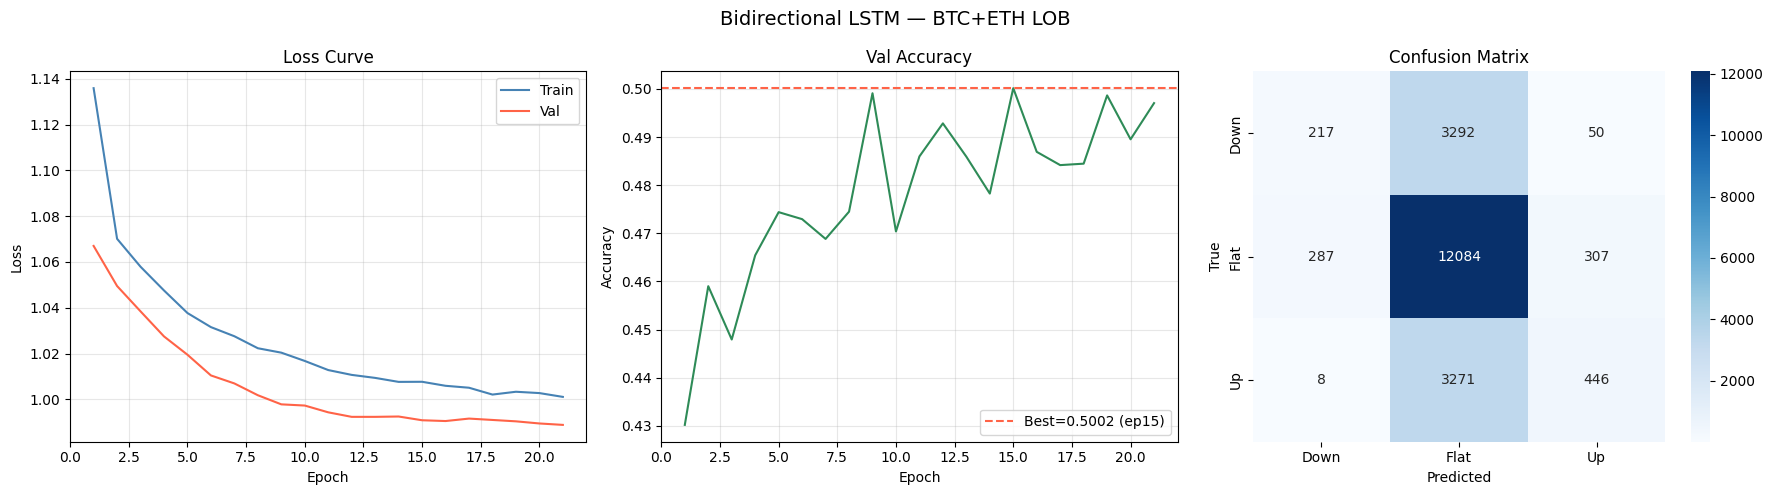

In [9]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ────────────────────────────────────────
SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 16
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 3e-4
PATIENCE    = 6

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Load processed data from CSV ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Load the full dataset for the main experiment
save_df = pd.read_csv("/content/drive/MyDrive/lob_full.csv")

split_idx = int((save_df['split'] == 'train').sum())

# CRITICAL: Exclude future_return from input features X_all to prevent data leakage!
X_all = save_df.drop(columns=['label', 'split', 'future_return']).values.astype(np.float32)
y_all = (save_df['label'].values + 1).astype(np.int64)   # {-1,0,1} -> {0,1,2}

# Extract all future_returns and store them for the final backtesting phase
returns_all = save_df['future_return'].values

print(f"X shape     : {X_all.shape}")
print(f"y shape     : {y_all.shape}")
print(f"n_features  : {X_all.shape[1]}")

# ── Dataset ────────────────────────────────────────────────
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


# ── DataLoaders ────────────────────────────────────────────
def build_loaders(X, y, split):
    """Chronological split -> normalise (fit on train) -> sliding-window DataLoaders."""

    embargo_gap = 10

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])

    X_te   = scaler.transform(X[split + embargo_gap :])
    y_tr, y_te = y[:split], y[split + embargo_gap :]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}")
    print(f"Test  samples : {len(test_loader.dataset):,}")
    print(f"Class weights (Down/Flat/Up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w, scaler

train_loader, test_loader, class_w, scaler = build_loaders(X_all, y_all, split_idx)

# ── Bidirectional LSTM ─────────────────────────────────────
class LOBLSTM(nn.Module):
    """
    Architecture
    ────────────
    Input (B, T, n_features)
      -> Linear projection  (n_features -> HIDDEN_SIZE)
      -> Bidirectional LSTM x N_LAYERS
      -> Concat last forward + backward hidden state  (2 * HIDDEN_SIZE)
      -> LayerNorm
      -> Classification head -> 3 classes (Down / Flat / Up)
    """

    def __init__(self, n_features: int):
        super().__init__()
        self.input_proj = nn.Linear(n_features, HIDDEN_SIZE)
        self.lstm = nn.LSTM(
            input_size    = HIDDEN_SIZE,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = N_LAYERS,
            batch_first   = True,
            bidirectional = False,
            dropout       = DROPOUT if N_LAYERS > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(HIDDEN_SIZE)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)   # forget-gate bias = 1
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)              # (B, T, HIDDEN_SIZE)
        _, (h_n, _) = self.lstm(x)          # h_n: (N_LAYERS, B, HIDDEN_SIZE)

        h = h_n[-1]                         # (B, HIDDEN_SIZE)
        h = self.norm(h)
        return self.head(h)


n_features = X_all.shape[1]
model      = LOBLSTM(n_features).to(DEVICE)
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model        : Bidirectional LSTM")
print(f"Input features: {n_features}")
print(f"Trainable params: {n_params:,}")
print(model)

# ── Training loop ──────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc, best_state, patience_cnt = 0.0, None, 0

print("=" * 60)
print("  Training Bidirectional LSTM")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    # ── train ──
    model.train(); running = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(yb)
    scheduler.step()
    train_loss = running / len(train_loader.dataset)

    # ── validate ──
    model.eval(); vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(Xb)
            vloss  += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total   += len(yb)
    val_loss = vloss / total
    val_acc  = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Ep {epoch:3d}/{EPOCHS} | Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc, patience_cnt = val_acc, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
            break

model.load_state_dict(best_state)
print(f"\nBest Val Accuracy: {best_acc:.4f}")

# ── Evaluation ─────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []
CONFIDENCE_THRESHOLD = 0.6

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))

        probs = torch.softmax(logits, dim=1)

        preds = torch.ones(len(yb), dtype=torch.long, device=DEVICE)

        preds[probs[:, 0] > CONFIDENCE_THRESHOLD] = 0
        preds[probs[:, 2] > CONFIDENCE_THRESHOLD] = 2

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

print("=" * 60)
print("  Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

# ── Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Bidirectional LSTM — BTC+ETH LOB", fontsize=14)

ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

best_ep = int(np.argmax(history["val_acc"])) + 1
axes[1].plot(ep, history["val_acc"], color="seagreen")
axes[1].axhline(best_acc, color="tomato", linestyle="--", label=f"Best={best_acc:.4f} (ep{best_ep})")
axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Down","Flat","Up"],
            yticklabels=["Down","Flat","Up"])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()




  Corrected Economic Evaluation (Event-Driven)
Total Trades (Round Trips): 348
Cumulative Net Return: 0.71%
Annualized Sharpe Ratio: 97.99


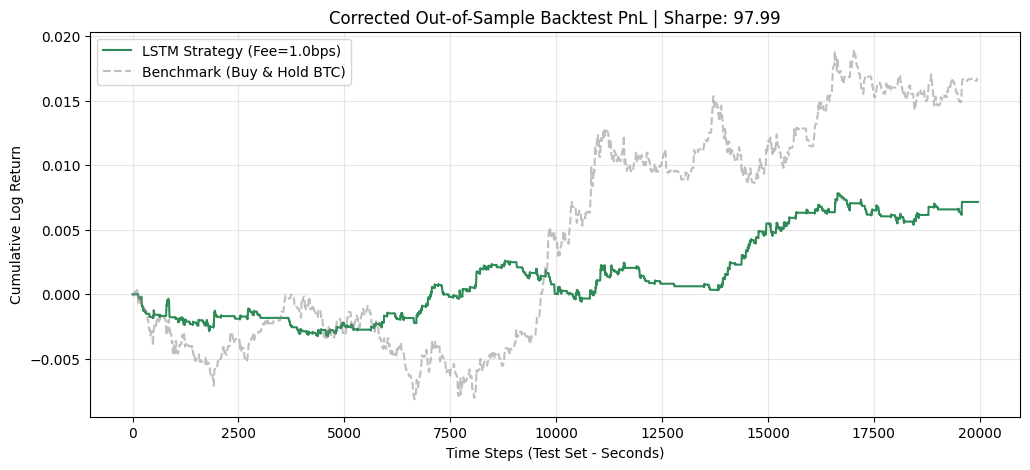

In [10]:
# ==========================================
# 8. Corrected Economic Evaluation (Event-Driven Backtester)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

def run_backtest_corrected(predictions, future_returns, fee_bps=1.5):
    """
    Corrected Event-Driven Backtest Engine (Eliminates Overlapping Returns Bug)
    Logic: Once a position is opened, it must be held for 10 seconds.
           All new signals during this holding period are completely ignored.
    """
    n = len(predictions)
    # Record the true net return for each second to calculate std dev and Sharpe
    net_pnl_1s = np.zeros(n)
    trades = 0
    i = 0

    while i < n:
        pred = predictions[i]

        # Ensure there is enough time left to hold for the full 10 seconds
        if i + 10 > n:
            break

        if pred == 2:  # Long signal received
            # Distribute the 10-second total return evenly across each of the 10 seconds
            net_pnl_1s[i : i+10] = future_returns[i] / 10.0
            # Deduct fee once for opening, and once for closing 10 seconds later
            net_pnl_1s[i] -= (fee_bps / 10000.0)
            net_pnl_1s[i+9] -= (fee_bps / 10000.0)

            trades += 1
            i += 10  # CRUCIAL FIX: Jump forward 10 seconds, ignoring signals while holding

        elif pred == 0:  # Short signal received
            net_pnl_1s[i : i+10] = -future_returns[i] / 10.0
            net_pnl_1s[i] -= (fee_bps / 10000.0)
            net_pnl_1s[i+9] -= (fee_bps / 10000.0)

            trades += 1
            i += 10  # CRUCIAL FIX: Jump forward 10 seconds

        else:  # Flat (Neutral position)
            net_pnl_1s[i] = 0
            i += 1   # Time advances normally by 1 second when flat

    cum_pnl = np.cumsum(net_pnl_1s)

    # Benchmark: Buy & Hold BTC (Sampled every 10 seconds to prevent overlap)
    cum_market = np.zeros(n)
    for j in range(0, n-10, 10):
        cum_market[j:j+10] = future_returns[j] / 10.0
    cum_market = np.cumsum(cum_market)

    # Recalculate Sharpe Ratio (Based on 1-second frequency, approx 31,536,000 seconds/year)
    annual_factor = np.sqrt(31536000)
    sharpe = np.mean(net_pnl_1s) / (np.std(net_pnl_1s) + 1e-8) * annual_factor

    print("\n" + "=" * 60)
    print("  Corrected Economic Evaluation (Event-Driven)")
    print("=" * 60)
    print(f"Total Trades (Round Trips): {trades}")
    print(f"Cumulative Net Return: {cum_pnl[-1]*100:.2f}%")
    print(f"Annualized Sharpe Ratio: {sharpe:.2f}")

    # Plot the realistic equity curve
    plt.figure(figsize=(12, 5))
    plt.plot(cum_pnl, label=f"LSTM Strategy (Fee={fee_bps}bps)", color='seagreen', linewidth=1.5)
    plt.plot(cum_market, label="Benchmark (Buy & Hold BTC)", color='gray', alpha=0.5, linestyle='--')
    plt.title(f"Corrected Out-of-Sample Backtest PnL | Sharpe: {sharpe:.2f}")
    plt.xlabel("Time Steps (Test Set - Seconds)")
    plt.ylabel("Cumulative Log Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Run the corrected backtest
run_backtest_corrected(y_pred, test_future_returns, fee_bps=1.0)